# Train, deploy and monitor a XGBoost regression model with the Amazon SageMaker 

[Amazon SageMaker](https://aws.amazon.com/sagemaker/) is a fully managed machine learning service. With SageMaker, you have the option of using the built-in algorithms or you can bring your own algorithms and frameworks. One of the features offered by Amazon SageMaker is [Model Monitor](https://docs.aws.amazon.com/sagemaker/latest/dg/model-monitor.html) which continuously monitors the quality of Amazon SageMaker machine learning models in production. With Model Monitor, you can set alerts that notify you when there are deviations from the specified baseline for the specified monitoring type. 

This notebook demonstrates how to use the SageMaker's [built-in XGBoost algorithm](https://docs.aws.amazon.com/sagemaker/latest/dg/xgboost.html) to train a regression model on the [MAMA-MIA dataset](https://github.com/LidiaGarrucho/MAMA-MIA?tab=License-1-ov-file#readme), deploy it on a SageMaker inference endpoint.


**Note:**

* This notebook should only be run from within a SageMaker notebook instance as it references SageMaker native APIs.
* At the time of writing this notebook, the most relevant latest version of the Jupyter notebook kernel for this notebook was `conda_python3` and this came built-in with SageMaker notebooks.
* This notebook uses CPU based instances for training.
* This notebook will create resources in the same AWS account and in the same region where this notebook is running.
<!-- 
**Table of Contents:**

1. [Complete prerequisites](#Complete%20prerequisites)

    1. [Check and configure access to the Internet](#Check%20and%20configure%20access%20to%20the%20Internet)

    2. [Check and upgrade required software versions](#Check%20and%20upgrade%20required%20software%20versions)
    
    3. [Check and configure security permissions](#Check%20and%20configure%20security%20permissions)

    4. [Organize imports](#Organize%20imports)
    
    5. [Create common objects](#Create%20common%20objects)

2. [Prepare the data](#Prepare%20the%20data)

    1. [Create the local directories](#Create%20the%20local%20directories)
    
    2. [Load the dataset and view the details](#Load%20the%20dataset%20and%20view%20the%20details)
    
    3. [(Optional) Visualize the dataset](#(Optional)%20Visualize%20the%20dataset)
    
    4. [Split the dataset into train, validate and test sets](#Split%20the%20dataset%20into%20train,%20validate%20and%20test%20sets)
    
    5. [Standardize the datasets](#Standardize%20the%20datasets)
    
    6. [Save the prepared datasets locally](#Save%20the%20prepared%20datasets%20locally)
    
    7. [Upload the prepared datasets to S3](#Upload%20the%20prepared%20datasets%20to%20S3)

3. [Perform training](#Perform%20training)

    1. [Set the training parameters](#Set%20the%20training%20parameters)
    
    2. [(Optional) Delete previous checkpoints](#(Optional)%20Delete%20previous%20checkpoints)
    
    3. [Run the training job](#Run%20the%20training%20job)

4. [Perform deployment](#Perform%20deployment)

    1. [Set the deployment parameters](#Set%20the%20deployment%20parameters)
    
    2. [Set the data capture parameters](#Set%20the%20data%20capture%20parameters)
    
    3. [(Optional) Delete previously deployed resources](#(Optional)%20Delete%20previously%20deployed%20resources)

    4. [Deploy the model](#Deploy%20the%20model)

5. [Create monitoring baselines](#Create%20monitoring%20baselines)

    1. [Data Quality Monitor](#Data%20Quality%20Monitor)
    
        1. [Prepare the dataset for baselining](#Prepare%20the%20dataset%20for%20baselining_DQ)
    
        2. [Create the Data Quality Monitor](#Create%20the%20Data%20Quality%20Monitor_DQ)

        3. [Generate the baseline](#Generate%20the%20baseline_DQ)
        
        4. [Display the generated baseline](#Display%20the%20generated%20baseline_DQ)

    2. [Model Quality Monitor](#Model%20Quality%20Monitor)
    
        1. [Prepare the dataset for baselining](#Prepare%20the%20dataset%20for%20baselining_MQ)
    
        2. [Create the Model Quality Monitor](#Create%20the%20Model%20Quality%20Monitor_MQ)
        
        3. [Generate the baseline](#Generate%20the%20baseline_MQ)
        
        4. [Display the generated baseline](#Display%20the%20generated%20baseline_MQ)
        
6. [Schedule monitoring jobs](#Schedule%20monitoring%20jobs)

    1. [Create Data Quality monitoring schedule](#Create%20Data%20Quality%20monitoring%20schedule)
    
    2. [Create Model Quality monitoring schedule](#Create%20Model%20Quality%20monitoring%20schedule)
    
    3. [Print schedule details](#Print%20schedule%20details)
    
    4. [Start/stop/delete schedules](#Start/stop/delete%20schedules)

7. [Send traffic to endpoint](#Send%20traffic%20to%20endpoint)

8. [Analyze monitoring executions](#Analyze%20monitoring%20executions)

    1. [View monitoring executions](#View%20monitoring%20executions)
    
    2. [View latest constraint violations](#View%20latest%20constraint%20violations)

9. [Generate alerts](#Generate%20alerts)

10. [Cleanup](#Cleanup) -->


##  1. Complete prerequisites <a id='Complete%20prerequisites'></a>

Check and complete the prerequisites.

###  A. Check and configure access to the Internet <a id='Check%20and%20configure%20access%20to%20the%20Internet'></a>

This notebook requires outbound access to the Internet to download the required software updates.  You can either provide direct Internet access (default) or provide Internet access through a VPC.  For more information on this, refer [here](https://docs.aws.amazon.com/sagemaker/latest/dg/appendix-notebook-and-internet-access.html).

### B. Check and upgrade required software versions  <a id='Check%20and%20upgrade%20required%20software%20versions'></a>

This notebook requires:
* [SageMaker Python SDK version 2.x](https://sagemaker.readthedocs.io/en/stable/v2.html)
* [Python 3.6.x](https://www.python.org/downloads/release/python-360/)
* [Boto3](https://boto3.amazonaws.com/v1/documentation/api/latest/index.html)

Note: If you get 'module not found' errors in the following cell, then uncomment the appropriate installation commands and install the modules.  Also, uncomment and run the kernel shutdown command.  When the kernel comes back, comment out the installation and kernel shutdown commands and run the following cell.  Now, you should not see any errors.

In [1]:
import boto3
import IPython
import sagemaker
import sys

"""
Last tested versions:
SageMaker Python SDK version : 2.41.0
Python version : 3.6.13 | packaged by conda-forge | (default, Feb 19 2021, 05:36:01) 
[GCC 9.3.0]
Boto3 version : 1.17.77
"""

# Install/upgrade the Sagemaker SDK and Boto3
#!{sys.executable} -m pip install -U sagemaker boto3
#IPython.Application.instance().kernel.do_shutdown(True)

# Get the current installed version of Sagemaker SDK, Python and Boto3
print('SageMaker Python SDK version : {}'.format(sagemaker.__version__))
print('Python version : {}'.format(sys.version))
print('Boto3 version : {}'.format(boto3.__version__))

sagemaker.config INFO - Fetched defaults config from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
SageMaker Python SDK version : 2.227.0
Python version : 3.11.11 | packaged by conda-forge | (main, Dec  5 2024, 14:17:24) [GCC 13.3.0]
Boto3 version : 1.34.162


###  C. Check and configure security permissions <a id='Check%20and%20configure%20security%20permissions'></a>

This notebook uses the IAM role attached to the underlying notebook instance.  This role should have the following permissions,

1. Full access to the S3 bucket that will be used to store training and output data.
2. Full access to launch training instances.
3. Full access to deploy models.
4. Full access to launch monitoring instances and schedules.
5. Access to write to CloudWatch logs and metrics.

To view the name of this role, run the following cell.

In [ ]:
print(sagemaker.get_execution_role())

###  D. Organize imports <a id='Organize%20imports'></a>

Organize all the library and module imports for later use.

In [2]:
import json
import logging
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import sklearn.model_selection
from sklearn.preprocessing import StandardScaler
from sagemaker.inputs import TrainingInput
from sagemaker.model_monitor import CronExpressionGenerator
from sagemaker.model_monitor import DataCaptureConfig
from sagemaker.model_monitor import DefaultModelMonitor
from sagemaker.model_monitor import ModelQualityMonitor
from sagemaker.model_monitor.dataset_format import DatasetFormat
from sagemaker.model_monitor.model_monitoring import EndpointInput
from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import CSVDeserializer
import datetime
import random

###  E. Create common objects <a id='Create%20common%20objects'></a>

Create common objects to be used in future steps in this notebook.

In [18]:
# Specify the S3 bucket name
s3_bucket = 'amazon-sagemaker-041601714418-us-east-1-cc1feccf34f4'

# Create the S3 Boto3 resource
s3_resource = boto3.resource('s3')
s3_bucket_resource = s3_resource.Bucket(s3_bucket)

# Create the SageMaker Boto3 client
sm_client = boto3.client('sagemaker')

# Base name to be used to create resources
nb_name = 'sm-xgboost-ca-housing-monitor-alert'

# Names of various resources
train_job_name = 'train-{}'.format(nb_name)
model_name = 'model-{}'.format(nb_name)
endpoint_name = 'endpt-{}'.format(nb_name)
dq_base_job_name = 'dq-{}'.format(nb_name)
mq_base_job_name = 'mq-{}'.format(nb_name)
dq_baseline_job_name_prefix = 'dq-bsl-job-{}'.format(nb_name)
mq_baseline_job_name_prefix = 'mq-bsl-job-{}'.format(nb_name)
dq_mon_schedule_name = 'dq-mon-sch-{}'.format(nb_name)
mq_mon_schedule_name = 'mq-mon-sch-{}'.format(nb_name)

# Names of local sub-directories in the notebook file system
data_dir = os.path.join(os.getcwd(), 'data/{}'.format(nb_name))
train_dir = os.path.join(os.getcwd(), 'data/{}/train'.format(nb_name))
val_dir = os.path.join(os.getcwd(), 'data/{}/validate'.format(nb_name))
test_dir = os.path.join(os.getcwd(), 'data/{}/test'.format(nb_name))
ground_truth_dir = os.path.join(os.getcwd(), 'data/{}/ground-truth'.format(nb_name))

# Location of the datasets file in the notebook file system
dataset_csv_file = os.path.join(os.getcwd(), 'datasets/california_housing.csv')

# Sub-folder names in S3
train_dir_s3_prefix = '{}/data/train'.format(nb_name)
val_dir_s3_prefix = '{}/data/validate'.format(nb_name)
test_dir_s3_prefix = '{}/data/test'.format(nb_name)
ground_truth_dir_s3_prefix = '{}/data/ground-truth'.format(nb_name)

# Location in S3 where the model checkpoint will be stored
model_checkpoint_s3_path = 's3://{}/{}/checkpoint/'.format(s3_bucket, nb_name)

# Location in S3 where the trained model will be stored
model_output_s3_path = 's3://{}/{}/output/'.format(s3_bucket, nb_name)

# Location in S3 that will contain all model monitor related files
model_monitor_s3_path = 's3://{}/{}/model-monitor'.format(s3_bucket, nb_name)

# Location in S3 where the data captured from the endpoint will be stored.
# Do not add a '/' at the end of the path here; it will be automatically added by the endpoint. If you add
# a '/' at the end, then the monitoring schedule will not be able to find the data capture files and your
# schedule will fail even if files are present in that S3 location.
data_capture_output_s3_path = '{}/data-capture'.format(model_monitor_s3_path)

# Location in S3 where the results from the baseline job will be stored
dq_baseline_job_output_s3_path = '{}/data-quality/baseline/'.format(model_monitor_s3_path)

# Location in S3 where the results from the baseline job will be stored
mq_baseline_job_output_s3_path = '{}/model-quality/baseline/'.format(model_monitor_s3_path)

# Location in S3 where the results from the monitoring job will be stored
# Do not add a '/' at the end of the path here
dq_mon_schedule_output_s3_path = '{}/data-quality/monitoring'.format(model_monitor_s3_path)

# Location in S3 where the results from the monitoring job will be stored
# Do not add a '/' at the end of the path here
mq_mon_schedule_output_s3_path = '{}/model-quality/monitoring'.format(model_monitor_s3_path)

# Set the inference id prefix to consistently use it when invoking the endpoint
# at various steps in this notebook
inference_id_prefix = 'FromNotebook_'

## 2. Prepare the data <a id='Prepare%20the%20data'></a>

The [California Housing dataset](https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html) consists of 20,640 observations on housing prices with 9 economic covariates.  These covariates are,

* MedianHouseValue
* MedianIncome
* HousingMedianAge
* TotalRooms
* TotalBedrooms
* Population
* Households
* Latitude
* Longitude

This dataset has been downloaded to the local `datasets` directory and modified as a CSV file with the feature names in the first row.  This will be used in this notebook.

The following steps will help with preparing the datasets for training, validation and testing.

### A) Create the local directories <a id='Create%20the%20local%20directories'></a>

Create the directories in the local system where the dataset will be copied to and processed.

In [13]:
# Create the local directories
os.makedirs(data_dir, exist_ok=True)
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)
os.makedirs(ground_truth_dir, exist_ok=True)

### B) Load the dataset and view the details <a id='Load%20the%20dataset%20and%20view%20the%20details'></a>

Check if the CSV file exists in the `datasets` directory and load it into a Pandas DataFrame.  Finally, print the details of the dataset.

In [4]:
# Check if the dataset file exists and proceed
dataset_csv_file = './datasets/clinical_and_imaging_info.csv'
if os.path.exists(dataset_csv_file):
    print('Dataset CSV file \'{}\' exists.'.format(dataset_csv_file))
    # Load the data into a Pandas DataFrame
    pd_data_frame = pd.read_csv(dataset_csv_file)
    # Print the first 5 records
    #print(pd_data_frame.head(5))
    # Describe the dataset
    print(pd_data_frame.describe())
else:
    print('Dataset CSV file \'{}\' does not exist.'.format(dataset_csv_file))

Dataset CSV file './datasets/clinical_and_imaging_info.csv' exists.
       bilateral_breast_cancer  multifocal_cancer  endocrine_therapy  \
count              1506.000000        1346.000000         290.000000   
mean                  0.019920           0.400446           0.010345   
std                   0.139773           0.490171           0.101357   
min                   0.000000           0.000000           0.000000   
25%                   0.000000           0.000000           0.000000   
50%                   0.000000           0.000000           0.000000   
75%                   0.000000           1.000000           0.000000   
max                   1.000000           1.000000           1.000000   

       anti_her2_neu_therapy          pcr  mastectomy_post_nac  \
count             290.000000  1491.000000           349.000000   
mean                0.279310     0.295104             0.541547   
std                 0.449436     0.456243             0.498986   
min                

### C) (Optional) Visualize the dataset <a id='(Optional)%20Visualize%20the%20dataset'></a>

Display the distributions in the dataset.

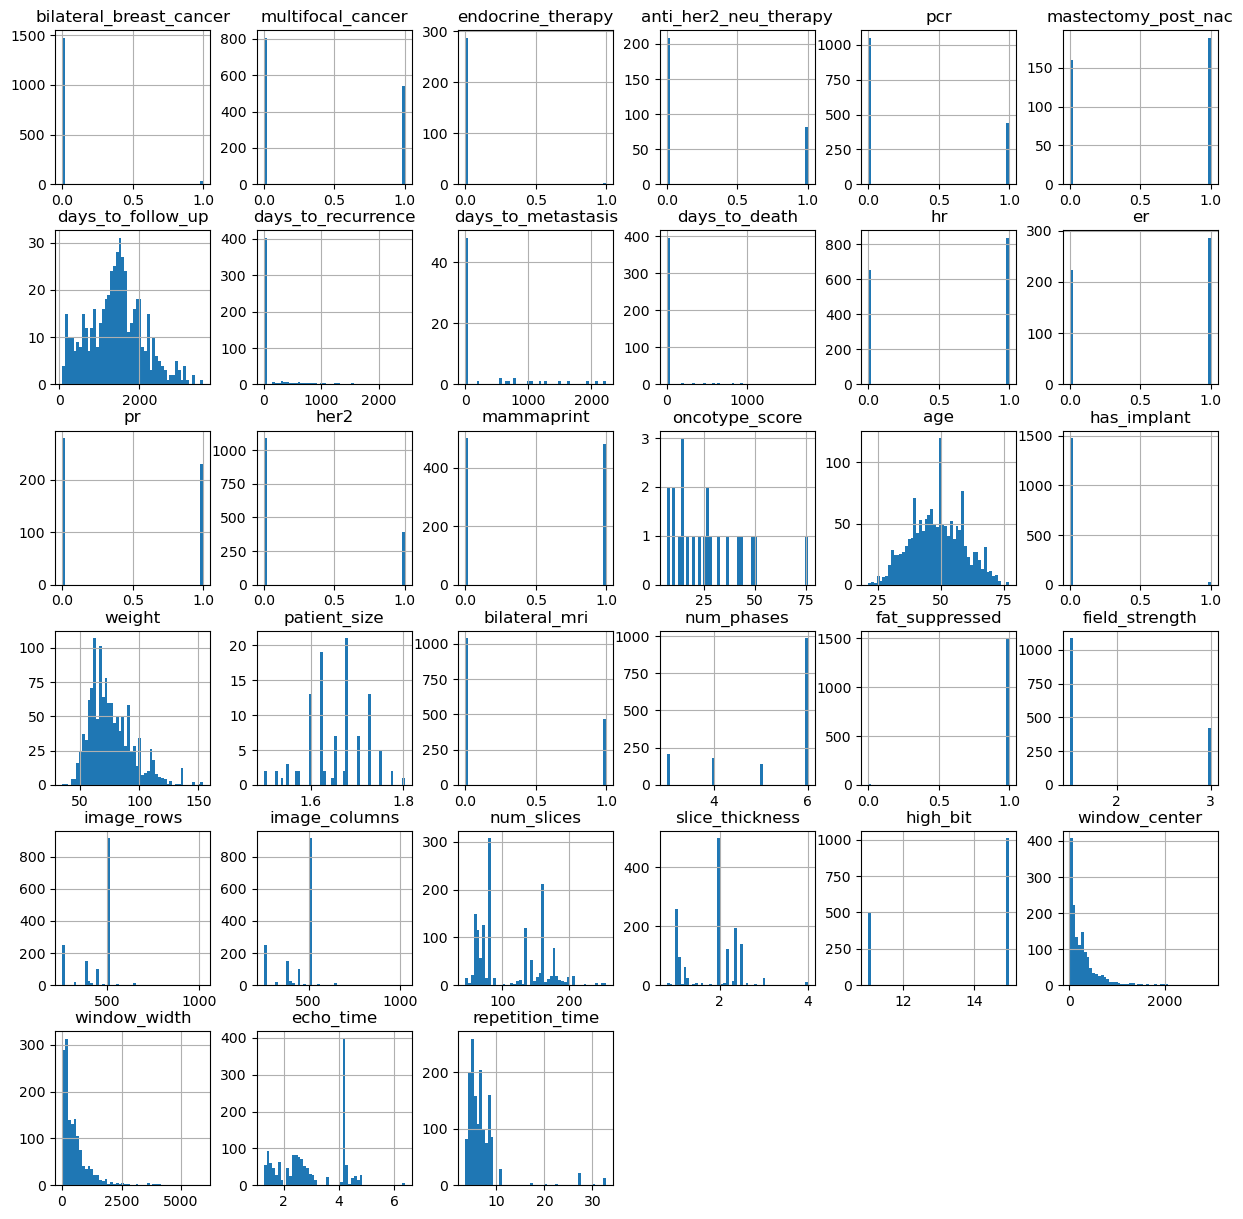

In [5]:
pd_data_frame.hist(bins=50, figsize=(15,15))
plt.show()

### D) Helper Functions

Here are some helper functions for data imputation and pre-processing

#### Data Imputation

In [6]:
def data_imputation(df):
    """
    Replace the missing value in the table with that of a random value from the same column.
    This is just for illustration purposes.
    """
    for col in df.columns[2:]:
        unique_values = df[col].unique()
        # remove NaN from the unique values
        unique_values = unique_values[~pd.isna(unique_values)]
        # Sample a random value from the unique values for each row with missing values
        # Iterate over the rows of the dataframe
        for i in range(len(df)):
            # Check if the value in the column is missing
            if pd.isna(df.loc[i, col]):
                # Sample a random value from the unique values
                unique_values_df = pd.DataFrame(unique_values, columns=[col])
                sampled_value = unique_values_df.sample(n=1).values[0][0]
                # Fill the missing value with the sampled value
                df.loc[i, col] = sampled_value
        
    return df

# Imputate the missing values in the dataset
processed_df = data_imputation(pd_data_frame)

#### Pre Processing Datasets
In this function, we will drop some of the columns from the data frame. Additionally, we will convert categorical values to numerical values. We will also save the categorical mapping on the disk

In [7]:
import os 
import pandas as pd

def preprocess_data(df, output_path):
    """
    Preprocess the data by reading from a CSV file, dropping unnecessary columns,
    and saving the cleaned data to a new CSV file.
    Parameters:
    - df: pandas dataframe
    - output_path: str, path to save the cleaned CSV file
    """


    # print the names of the columns
    print(df.columns)

    # Drop rows with matching values in 'dataset'
    df = df.drop(df[df['dataset'] == 'DUKE'].index)

    # Drop unnecessary columns. Some of these columns are related to the associated imaging parameters so not needed 
    unneccessary_columns = ['patient_id', 'dataset',\
        'days_to_metastasis', 'days_to_death',\
        'mammaprint', 'oncotype_score', 'image_rows', 'image_columns',\
        'view',	'bilateral_mri','num_phases', 'fat_suppressed',	'field_strength',\
        'image_rows', 'image_columns', 'num_slices', 'pixel_spacing', 'slice_thickness', \
        'site',	'manufacturer',	'scanner_model', 'high_bit', 'window_center',\
        'window_width',	'echo_time', 'repetition_time',	'acquisition_times',\
        'acquisition_date',	'tcia_series_uid']

    df = df.drop(columns=unneccessary_columns)
    
    categorical_columns = ['nottingham_grade', 'tumor_subtype', 'menopause', 'nac_agent', \
        'ethnicity', 'bmi_group', 'breast_density']
    mappings = {}
    for col in categorical_columns:
        df[col] = df[col].astype('category')
        mappings[col] = dict(enumerate(df[col].cat.categories))
        df[col] = df[col].cat.codes

    with open(os.path.join(output_path, 'mappings.json'), 'w') as f:
        json.dump(mappings,f, indent=2) 
    
    return df

df = preprocess_data(processed_df, './datasets')

Index(['patient_id', 'dataset', 'bilateral_breast_cancer', 'multifocal_cancer',
       'nac_agent', 'endocrine_therapy', 'anti_her2_neu_therapy', 'pcr',
       'mastectomy_post_nac', 'days_to_follow_up', 'days_to_recurrence',
       'days_to_metastasis', 'days_to_death', 'hr', 'er', 'pr', 'her2',
       'mammaprint', 'oncotype_score', 'nottingham_grade', 'tumor_subtype',
       'age', 'menopause', 'ethnicity', 'has_implant', 'weight',
       'patient_size', 'bmi_group', 'breast_density', 'view', 'bilateral_mri',
       'num_phases', 'fat_suppressed', 'field_strength', 'image_rows',
       'image_columns', 'num_slices', 'pixel_spacing', 'slice_thickness',
       'site', 'manufacturer', 'scanner_model', 'high_bit', 'window_center',
       'window_width', 'echo_time', 'repetition_time', 'acquisition_times',
       'acquisition_date', 'tcia_series_uid'],
      dtype='object')


### D) Split the dataset into train, validate and test sets <a id='Split%20the%20dataset%20into%20train,%20validate%20and%20test%20sets'></a>

Split the dataset into train, validate and test sets after shuffling.  Split further into x and y sets.

In [9]:
train, test = sklearn.model_selection.train_test_split(df, test_size=0.2,
                                                       random_state=35, shuffle=True)
# Split the train dataset further into train and validation datasets after shuffling
train, val = sklearn.model_selection.train_test_split(train, test_size=0.1,
                                                      random_state=25, shuffle=True)

### E) Standardize the datasets <a id='Standardize%20the%20datasets'></a>

* Standardize the x columns of the train dataset using the `fit_transform()` function of `StandardScaler`.
* Standardize the x columns of the validate and test datasets using the `transform()` function of `StandardScaler`.

In [10]:
y_train = train['days_to_follow_up']
y_val = val['days_to_follow_up']
y_test = test['days_to_follow_up']

x_train = train.drop(columns=['days_to_follow_up'])
x_val = val.drop(columns=['days_to_follow_up'])
x_test = test.drop(columns=['days_to_follow_up'])

# Standardize the dataset
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

### F) Save the prepared datasets locally <a id='Save%20the%20prepared%20datasets%20locally'></a>

Save the prepared train, validate and test datasets to local directories.  Prior to saving, concatenate x and y columns as needed.  Create the directories if they don't exist.

In [14]:

# Save the prepared dataset (in numpy format) to the local directories as csv files
np.savetxt(os.path.join(train_dir, 'train.csv'),
           np.concatenate((np.expand_dims(y_train.to_numpy(), axis=1), x_train), axis=1), delimiter=',')
np.savetxt(os.path.join(train_dir, 'train_x.csv'), x_train)
np.savetxt(os.path.join(train_dir, 'train_y.csv'), y_train.to_numpy())

np.savetxt(os.path.join(val_dir, 'validate.csv'),
           np.concatenate((np.expand_dims(y_val.to_numpy(), axis=1), x_val), axis=1), delimiter=',')
np.savetxt(os.path.join(val_dir, 'validate_x.csv'), x_val)
np.savetxt(os.path.join(val_dir, 'validate_y.csv'), y_val.to_numpy())

np.savetxt(os.path.join(test_dir, 'test.csv'),
            np.concatenate((np.expand_dims(y_test.to_numpy(), axis=1), x_test), axis=1), delimiter=',')
np.savetxt(os.path.join(test_dir, 'test_x.csv'), x_test)
np.savetxt(os.path.join(test_dir, 'test_y.csv'), y_test.to_numpy())

### G) Upload the prepared datasets to S3 <a id='Upload%20the%20prepared%20datasets%20to%20S3'></a>

Upload the datasets from the local directories to appropriate sub-directories in the specified S3 bucket.

In [ ]:
train_dir_s3_prefix
s3_bucket

In [20]:
# Upload the data to S3
train_dir_s3_path = sagemaker.Session().upload_data(path='./data/{}/train/'.format(nb_name),
                                                          bucket=s3_bucket,
                                                          key_prefix=train_dir_s3_prefix)
val_dir_s3_path = sagemaker.Session().upload_data(path='./data/{}/validate/'.format(nb_name),
                                                        bucket=s3_bucket,
                                                        key_prefix=val_dir_s3_prefix)
test_dir_s3_path = sagemaker.Session().upload_data(path='./data/{}/test/'.format(nb_name),
                                                         bucket=s3_bucket,
                                                         key_prefix=test_dir_s3_prefix)

# Capture the S3 locations for the uploaded datasets
train_s3_path = '{}/train.csv'.format(train_dir_s3_path)
train_x_s3_path = '{}/train_x.csv'.format(train_dir_s3_path)
train_y_s3_path = '{}/train_y.csv'.format(train_dir_s3_path)
train_x_with_header_s3_path = '{}/train_x_with_header.csv'.format(train_dir_s3_path)
val_s3_path = '{}/validate.csv'.format(val_dir_s3_path)
val_x_s3_path = '{}/validate_x.csv'.format(val_dir_s3_path)
val_y_s3_path = '{}/validate_y.csv'.format(val_dir_s3_path)
test_s3_path = '{}/test.csv'.format(test_dir_s3_path)
test_x_s3_path = '{}/test_x.csv'.format(test_dir_s3_path)
test_y_s3_path = '{}/test_y.csv'.format(test_dir_s3_path)

sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix


##  3. Perform training <a id='Perform%20training'></a>

In this step, SageMaker's [built-in XGBoost algorithm](https://docs.aws.amazon.com/sagemaker/latest/dg/xgboost.html) is used to train a regression model on the [California Housing dataset](https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html).

Note: Although you can perform validation along with training, we will not do that here.  Instead, we will run through the validation dataset on the deployed model to create a baseline for the Model Monitor.

### A) Set the training parameters <a id='Set%20the%20training%20parameters'></a>

1. Inputs - S3 location of the training data.
2. Hyperparameters.
3. Training instance details:

    1. Instance count
    
    2. Instance type
    
    3. The max run time of the training job
    
    4. (Optional) Use Spot instances.  For more info, refer [here](https://docs.aws.amazon.com/sagemaker/latest/dg/model-managed-spot-training.html).
    
    5. (Optional) The max wait for Spot instances, if using Spot.  This should be larger than the max run time.
    
4. Base job name
5. Appropriate local and S3 directories that will be used by the training job.

In [21]:
# Set the input data input along with their content types
train_input = TrainingInput(train_s3_path, content_type='text/csv')
inputs = {'train':train_input}

# Set the hyperparameters
hyperparameters = {
        'objective':'reg:squarederror',
        'max_depth':'6',
        'eta':'0.3',
        'alpha':'3',
        'colsample_bytree':'0.7',
        'num_round':'100'}

# Set the instance count, instance type, volume size, options to use Spot instances and other parameters
train_instance_count = 1
train_instance_type = 'ml.m5.xlarge'
train_instance_volume_size_in_gb = 5
#use_spot_instances = True
#spot_max_wait_time_in_seconds = 5400
use_spot_instances = False
spot_max_wait_time_in_seconds = None
max_run_time_in_seconds = 3600
region_name = sagemaker.Session().boto_region_name
algorithm_name = 'xgboost'
algorithm_version = '1.2-1'
py_version = 'py37'
# Get the container image URI for the specified parameters
container_image_uri = sagemaker.image_uris.retrieve(framework=algorithm_name,
                                                    region=region_name,
                                                    version=algorithm_version,
                                                    py_version=py_version,
                                                    instance_type=train_instance_type,
                                                    image_scope='training')

# Set the training container related parameters
container_log_level = logging.INFO

# Location where the model checkpoints will be stored locally in the container before being uploaded to S3
model_checkpoint_local_dir = '/opt/ml/checkpoints/'

# Location where the trained model will be stored locally in the container before being uploaded to S3
model_local_dir = '/opt/ml/model'

sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix


### B) (Optional) Delete previous checkpoints <a id='(Optional)%20Delete%20previous%20checkpoints'></a>

If model checkpoints from previous trainings are found in the S3 checkpoint location specified in the previous step, then training will resume from those checkpoints.  In order to start a fresh training, run the following code cell to delete all checkpoint objects from S3.

In [22]:
# Delete the checkpoints if you want to train from the beginning; else ignore this code cell
for checkpoint_file in s3_bucket_resource.objects.filter(Prefix='{}/checkpoint/'.format(nb_name)):
    checkpoint_file_key = checkpoint_file.key
    print('Deleting {} ...'.format(checkpoint_file_key))
    s3_resource.Object(s3_bucket_resource.name, checkpoint_file_key).delete()

### C) Run the training job <a id='Run%20the%20training%20job'></a>

Prepare the `estimator` and call the `fit()` method.  This will pull the container containing the specified version of the algorithm in the AWS region and run the training job in the specified type of EC2 instance(s).  The training data will be pulled from the specified location in S3 and training results and checkpoints will be written to the specified locations in S3.

Note: SageMaker Debugger is disabled.

In [ ]:
# Create the estimator
estimator = sagemaker.estimator.Estimator(
    image_uri=container_image_uri,
    checkpoint_local_path=model_checkpoint_local_dir,
    checkpoint_s3_uri=model_checkpoint_s3_path,
    model_dir=model_local_dir,
    output_path=model_output_s3_path,
    instance_type=train_instance_type,
    instance_count=train_instance_count,
    use_spot_instances=use_spot_instances,
    max_wait=spot_max_wait_time_in_seconds,
    max_run=max_run_time_in_seconds,
    hyperparameters=hyperparameters,
    role=sagemaker.get_execution_role(),
    base_job_name=train_job_name,
    framework_version=algorithm_version,
    py_version=py_version,
    container_log_level=container_log_level,
    script_mode=False,
    debugger_hook_config=False,
    disable_profiler=True)

# Perform the training
estimator.fit(inputs, wait=True)

sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.TrainingJob.VpcConfig.Subnets
sagemaker.config INFO - Applied value from config key = SageMaker.TrainingJob.VpcConfig.SecurityGroupIds
2025-04-30 06:32:47 Starting - Starting the training job......

##  4. Perform deployment <a id='Perform%20deployment'></a>

In this step, we will deploy the model generated in the training step earlier.  For deployment, we will use [SageMaker Python SDK version 2.x](https://sagemaker.readthedocs.io/en/stable/v2.html) and directly call the `deploy()` method on the `estimator` object used for training.  This type of deployment is not recommended for anything beyond development purposes.

### A) Set the deployment parameters <a id='Set%20the%20deployment%20parameters'></a>

1. Deployment instance details:

    1. Instance count
    
    2. Instance type
    
    3. The Elastic Inference accelerator type
    
2. Serializer and deserializer - set them to CSV as the data will be in CSV format.

In [ ]:
# Set the instance count, instance type, endpoint name and other parameters
deploy_initial_instance_count = 1
deploy_instance_type = 'ml.m5.xlarge'
accelerator_type = None
serializer = CSVSerializer(content_type='text/csv')
deserializer = CSVDeserializer(encoding='utf-8', accept='text/csv')

### B) Set the data capture parameters <a id='Set%20the%20data%20capture%20parameters'></a>

Setting up data capture will automatically capture the specified request/response data for calls made to the SageMaker inference endpoint and store them in the specified location in S3.  This is required for the Model Monitor to work.

In [ ]:
# Set the data capture configuration
data_capture_config = DataCaptureConfig(
    enable_capture = True,
    sampling_percentage=100,
    destination_s3_uri=data_capture_output_s3_path,
    capture_options=['REQUEST', 'RESPONSE'],
    csv_content_types=['text/csv'],
    json_content_types=None,
    sagemaker_session=sagemaker.Session())

### C) (Optional) Delete previously deployed resources <a id='(Optional)%20Delete%20previously%20deployed%20resources'></a>

This step deletes the model, endpoint configuration and endpoint.  You may want to run this step if you are running only some parts of this notebook especially deploying after re-training the model.

Note: You may run into errors if the model, endpoint or endpoint config does not exist.  This may be due to partial deletes in the past.  In this case, comment out the appropriate lines of the code and run the rest.  Alternatively, you can go to the [SageMaker console](https://console.aws.amazon.com/sagemaker/home), switch to the required region and delete these resources.

In [ ]:
# Delete the model, endpoint configuration and endpoint
endpoint_config_name = sm_client.describe_endpoint(EndpointName=endpoint_name)['EndpointConfigName']
sm_client.delete_model(ModelName=model_name)
sm_client.delete_endpoint(EndpointName=endpoint_name)
sm_client.delete_endpoint_config(EndpointConfigName=endpoint_config_name)

### D) Deploy the model <a id='Deploy%20the%20model'></a>

Deploy the model created in the training process to a SageMaker real-time inference endpoint using the parameters specified in the previous step.

Note: This step automatically creates the endpoint configuration before creating the endpoint.

In [ ]:
# Deploy the model and automatically create the endpoint configuration in the process
predictor = estimator.deploy(initial_instance_count=deploy_initial_instance_count,
                             instance_type=deploy_instance_type,
                             accelerator_type=accelerator_type,
                             serializer=serializer,
                             deserializer=deserializer,
                             model_name=model_name,
                             endpoint_name=endpoint_name,
                             data_capture_config=data_capture_config,
                             wait=True)

In [ ]:
# Iterate over the validate dataset and call the predictor for each row
predictions_labels_list = []
predictions_labels_list.append('prediction,label\n')
x_val_rows = x_val.tolist()
y_val_rows = y_val.to_numpy()
for index, x_val_row in enumerate(x_val_rows, start=1):
    x_val_row_string = ','.join(map(str, x_val_row))
    inference_id = '{}{}'.format(inference_id_prefix, index)
    predicted_object = predictor.predict(data=x_val_row_string,
                                         target_model=None,
                                         target_variant=None,
                                         inference_id=inference_id)
    predicted_value = float(predicted_object[0][0])
    predictions_labels_list.append('{},{}\n'.format(predicted_value, y_val_rows[index - 1][0]))

# Write the predictions-labels file to the local directory
predictions_labels_file_name = 'predictions_labels.csv'
predictions_labels_file_path = os.path.join(val_dir, predictions_labels_file_name)
with open(predictions_labels_file_path, 'wt') as predictions_labels_file:
    predictions_labels_file.write(''.join(predictions_labels_list))

# Upload the predictions-labels data to S3
predictions_labels_s3_path = sagemaker.Session().upload_data(path='./data/{}/validate/{}'.format(nb_name,
                                                                                            predictions_labels_file_name),
                                                        bucket=s3_bucket,
                                                        key_prefix=val_dir_s3_prefix)

## 7. Send traffic to endpoint <a id='Send%20traffic%20to%20endpoint'></a>

In this step, we will send traffic to the endpoint by calling the `predict()` method on the `predictor` object.  This will automatically capture the request/response data in S3 as per the `DataCaptureConfig` defined in the deployment step.  Based on the schedules, each of the monitors that we defined in the earlier steps will read this data and compare with their baselines.  If any violations are found, a `constraint_violations.json` file will be generated by each monitor.

In this step, you can introduce data quality and model quality issues by changing the x columns being sent to the `predictor`.  This will help in understanding the capabilities of the monitors in detail.

This noteboook will use the test dataset to send the traffic for inference.  This step will iterate through the test dataset and complete when done.  This means that the monitors may not see captured data in every monitoring cycle and will report the status of the monitoring execution as 'Failed'.  If you like data to be generated continuously, you can modify this code but keep in mind that you will incur unnecessary costs if you forget to stop this after your testing.

In [ ]:
# When you send this traffic to the endpoint, you will observe both Data Quality
# and Model Quality violations when monitoring completes.  This is based on the
# assumption that you have not changed the data or the processing logic in this
# notebook.

# Iterate over the test data and call the predictor for each row
x_test_rows = x_test.tolist()
for index, x_test_row in enumerate(x_test_rows, start=1):
    x_test_row_string = ','.join(map(str, x_test_row))
    # Auto-generate an inference-id to track the request/response in the captured data
    inference_id = '{}{}'.format(inference_id_prefix, index)
    predicted_object = predictor.predict(data=x_test_row_string,
                                         target_model=None,
                                         target_variant=None,
                                         inference_id=inference_id)
    predicted_value = float(predicted_object[0][0])
    print('{}: Prediction for \'{}\' is {}'.format(inference_id, x_test_row_string, predicted_value))

## 10. Cleanup <a id='Cleanup'></a>

As a best practice, you should delete resources and S3 objects when no longer required.  This will help you avoid incurring unncessary costs.

This step will cleanup the resources and S3 objects created by this notebook.

In [ ]:
# Delete the model, endpoint configuration and endpoint
predictor.delete_model()
predictor.delete_endpoint()

In [ ]:
# Delete data from S3 bucket
for file in s3_bucket_resource.objects.filter(Prefix='{}/'.format(nb_name)):
    file_key = file.key
    print('Deleting {} ...'.format(file_key))
    s3_resource.Object(s3_bucket_resource.name, file_key).delete()